In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# import json
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# from statsmodels.formula.api import ols
# from statsmodels.stats.anova import anova_lm

# # ── Load participants CSV ────────────────────────────────────
# participants_df = pd.read_csv("/Users/rachelsong/Desktop/Movesense/COGS 402 Participants - Sheet.csv")

# # Fix column names (strip spaces, standardize)
# participants_df.columns = [c.strip().lower().replace(' ', '_') for c in participants_df.columns]

# print("Columns after cleaning:", participants_df.columns.tolist())
# print(participants_df.head(10).to_string())

# # ── Build (sensor_id, cohort) -> participant mapping ─────────
# # Sensors are reused across cohorts so we need BOTH to identify a participant
# sensor_cohort_to_participant = {}
# for _, row in participants_df.iterrows():
#     sensor_id = str(int(row['sensor_id']))
#     cohort = row['participant_cohort']
#     sensor_cohort_to_participant[(sensor_id, cohort)] = int(row['participant_id'])

# # ── Build cohort -> conditions mapping ──────────────────────
# cohort_conditions = {}
# for _, row in participants_df.iterrows():
#     cohort = row['participant_cohort']
#     cond = row['condition']
#     if pd.notna(cond) and str(cond).strip():
#         cond_str = str(cond).strip()
#         parts = [c.strip() for c in cond_str.split(',')]
#         if len(parts) == 2:
#             cohort_conditions[cohort] = {
#                 'phase1': parts[0],
#                 'phase2': parts[1]
#             }

# # ── Build cohort -> ordered participant IDs ──────────────────
# cohort_participants = {}
# for cohort, group in participants_df.groupby('participant_cohort'):
#     cohort_participants[cohort] = list(group['participant_id'].astype(int))

# print(f"\n✓ Participant data loaded")
# print(f"  {len(sensor_cohort_to_participant)} sensor-cohort pairs mapped")
# print(f"  {len(cohort_conditions)} cohorts with conditions")

# # ── Load session results and map to conditions ───────────────
# hr_sync_dir = Path("/Users/rachelsong/Desktop/Movesense/hr_synchrony_results")

# records = []

# for session_dir in sorted(hr_sync_dir.iterdir()):
#     if not session_dir.is_dir():
#         continue

#     results_file = session_dir / 'synchrony_results.json'
#     metadata_file = Path("/Users/rachelsong/Desktop/Movesense/processed_data") / session_dir.name / 'metadata.json'

#     if not results_file.exists() or not metadata_file.exists():
#         print(f"⚠️ Skipping {session_dir.name} — missing files")
#         continue

#     with open(results_file) as f:
#         results = json.load(f)
#     with open(metadata_file) as f:
#         metadata = json.load(f)

#     # Get cohort directly from metadata
#     cohort = metadata.get('cohort')
#     if cohort is None:
#         print(f"⚠️ Skipping {session_dir.name} — no cohort in metadata")
#         continue

#     # Trim full sensor ID to last 4 digits to match CSV
#     sensor1 = str(metadata['sensor_1'])[-4:] if 'sensor_1' in metadata else None
#     sensor2 = str(metadata['sensor_2'])[-4:] if 'sensor_2' in metadata else None

#     if sensor1 is None or sensor2 is None:
#         print(f"⚠️ Skipping {session_dir.name} — no sensor keys in metadata")
#         continue

#     # Look up participants using sensor + cohort together
#     if (sensor1, cohort) not in sensor_cohort_to_participant:
#         print(f"⚠️ Skipping {session_dir.name} — sensor {sensor1} not found in cohort {cohort}")
#         continue
#     if (sensor2, cohort) not in sensor_cohort_to_participant:
#         print(f"⚠️ Skipping {session_dir.name} — sensor {sensor2} not found in cohort {cohort}")
#         continue

#     p1_id = sensor_cohort_to_participant[(sensor1, cohort)]
#     p2_id = sensor_cohort_to_participant[(sensor2, cohort)]

#     if cohort not in cohort_conditions:
#         print(f"⚠️ Skipping {session_dir.name} — cohort '{cohort}' has no condition data")
#         continue

#     ordered = cohort_participants.get(cohort, [])
#     if len(ordered) != 4:
#         print(f"⚠️ Skipping {session_dir.name} — cohort {cohort} has {len(ordered)} participants, expected 4")
#         continue

#     p1_pos = ordered.index(p1_id) if p1_id in ordered else -1
#     p2_pos = ordered.index(p2_id) if p2_id in ordered else -1

#     if p1_pos == -1 or p2_pos == -1:
#         print(f"⚠️ Skipping {session_dir.name} — participants {p1_id}, {p2_id} not found in cohort {cohort}")
#         continue

#     positions = sorted([p1_pos, p2_pos])

#     if positions in [[0, 1], [2, 3]]:
#         phase = 1
#         condition_code = cohort_conditions[cohort]['phase1']
#     elif positions in [[0, 2], [1, 3]]:
#         phase = 2
#         condition_code = cohort_conditions[cohort]['phase2']
#     else:
#         print(f"⚠️ Skipping {session_dir.name} — unexpected pairing {positions}")
#         continue

#     # Parse condition code (EA, NB, NA, EB)
#     emotion = 'Emotional' if condition_code[0] == 'E' else 'Neutral'
#     recipe = 'Apple' if condition_code[1] == 'A' else 'Banana'

#     # Fisher z-transform
#     r = results['overall_r']
#     r_clipped = np.clip(r, -0.9999, 0.9999)
#     fisher_z = np.arctanh(r_clipped)

#     records.append({
#         'session': session_dir.name,
#         'cohort': cohort,
#         'participant_1_id': p1_id,
#         'participant_2_id': p2_id,
#         'phase': phase,
#         'condition_code': condition_code,
#         'emotion': emotion,
#         'recipe': recipe,
#         'overall_r': r,
#         'fisher_z': fisher_z,
#         'duration_seconds': results['duration_seconds']
#     })

# print(f"\nTotal records collected: {len(records)}")
# df = pd.DataFrame(records)

# if df.empty:
#     print("⚠️ No records collected — check warnings above")
# else:
#     print(f"✓ Mapped {len(df)} sessions to conditions")
#     print(f"\nCondition breakdown:")
#     print(df.groupby(['emotion', 'recipe']).size().reset_index(name='n'))
#     print(f"\nFull dataset:")
#     print(df[['session', 'cohort', 'emotion', 'recipe', 'overall_r', 'fisher_z']].to_string())

#     # ── Descriptive statistics ───────────────────────────────
#     print(f"\n{'='*60}")
#     print("DESCRIPTIVE STATISTICS")
#     print(f"{'='*60}")
#     desc = df.groupby(['emotion', 'recipe'])['fisher_z'].agg(['mean', 'std', 'count'])
#     desc.columns = ['Mean Fisher Z', 'SD', 'N']
#     print(desc)

#     # ── 2x2 ANOVA ───────────────────────────────────────────
#     print(f"\n{'='*60}")
#     print("2x2 ANOVA RESULTS")
#     print(f"{'='*60}")

#     model = ols('fisher_z ~ C(emotion) + C(recipe) + C(emotion):C(recipe)', data=df).fit()
#     anova_table = anova_lm(model, typ=2)
#     print(anova_table)

#     # Partial eta squared
#     anova_table['partial_eta_sq'] = anova_table['sum_sq'] / (
#         anova_table['sum_sq'] + anova_table.loc['Residual', 'sum_sq']
#     )
#     print(f"\nPartial Eta Squared:")
#     for idx in anova_table.index[:-1]:
#         print(f"  {idx}: η²p = {anova_table.loc[idx, 'partial_eta_sq']:.3f}")

#     # ── Plot means ──────────────────────────────────────────
#     fig, ax = plt.subplots(figsize=(8, 6))
#     colors = {'Apple': '#2E86AB', 'Banana': '#F18F01'}

#     for recipe in ['Apple', 'Banana']:
#         subset = df[df['recipe'] == recipe].groupby('emotion')['fisher_z'].agg(['mean', 'sem'])
#         ax.plot(subset.index, subset['mean'], 'o-', linewidth=2, markersize=8,
#                 color=colors[recipe], label=recipe)
#         ax.errorbar(subset.index, subset['mean'], yerr=subset['sem'],
#                     fmt='none', color=colors[recipe], capsize=5)

#     ax.set_xlabel('Emotional Condition', fontsize=12)
#     ax.set_ylabel('HR Synchrony (Fisher Z)', fontsize=12)
#     ax.set_title('HR Synchrony by Condition and Recipe', fontsize=14, fontweight='bold')
#     ax.legend(title='Recipe', fontsize=11)
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.savefig("/Users/rachelsong/Desktop/Movesense/anova_results.png", dpi=150, bbox_inches='tight')
#     plt.show()

#     # ── Save results ─────────────────────────────────────────
#     df.to_csv("/Users/rachelsong/Desktop/Movesense/anova_data.csv", index=False)
#     anova_table.to_csv("/Users/rachelsong/Desktop/Movesense/anova_table.csv")
#     print(f"\n✓ Results saved to /Users/rachelsong/Desktop/Movesense/")

✓ Participant data loaded — 14 cohorts with conditions
✓ 2025_11_28-22_39_22 | Emotional Apple | HR r=0.132 | HRV r=0.571
✓ 2025_11_28-22_42_49 | Emotional Apple | HR r=0.238 | HRV r=-0.027
✓ 2025_11_28-23_07_21 | Neutral Banana | HR r=0.058 | HRV r=0.395
✓ 2025_11_28-23_07_45 | Neutral Banana | HR r=0.176 | HRV r=-0.091
✓ 2025_12_01-22_31_58 | Neutral Banana | HR r=0.062 | HRV r=-0.070
✓ 2025_12_01-22_37_05 | Neutral Banana | HR r=-0.071 | HRV r=0.200
✓ 2025_12_01-23_08_42 | Emotional Apple | HR r=0.033 | HRV r=-0.071
✓ 2025_12_01-23_08_47 | Emotional Apple | HR r=-0.230 | HRV r=-0.214
✓ 2025_12_16-22_00_52 | Neutral Apple | HR r=0.076 | HRV r=0.164
✓ 2025_12_16-22_01_30 | Neutral Apple | HR r=0.242 | HRV r=-0.104
✓ 2025_12_16-22_29_50 | Emotional Banana | HR r=0.152 | HRV r=0.183
✓ 2025_12_16-22_32_49 | Emotional Banana | HR r=0.178 | HRV r=0.191
✓ 2025_12_19-19_20_59 | Emotional Banana | HR r=-0.073 | HRV r=0.151
⚠️ No HR sync results for 2025_12_19-19_21_15 — skipping
✓ 2025_12_19-

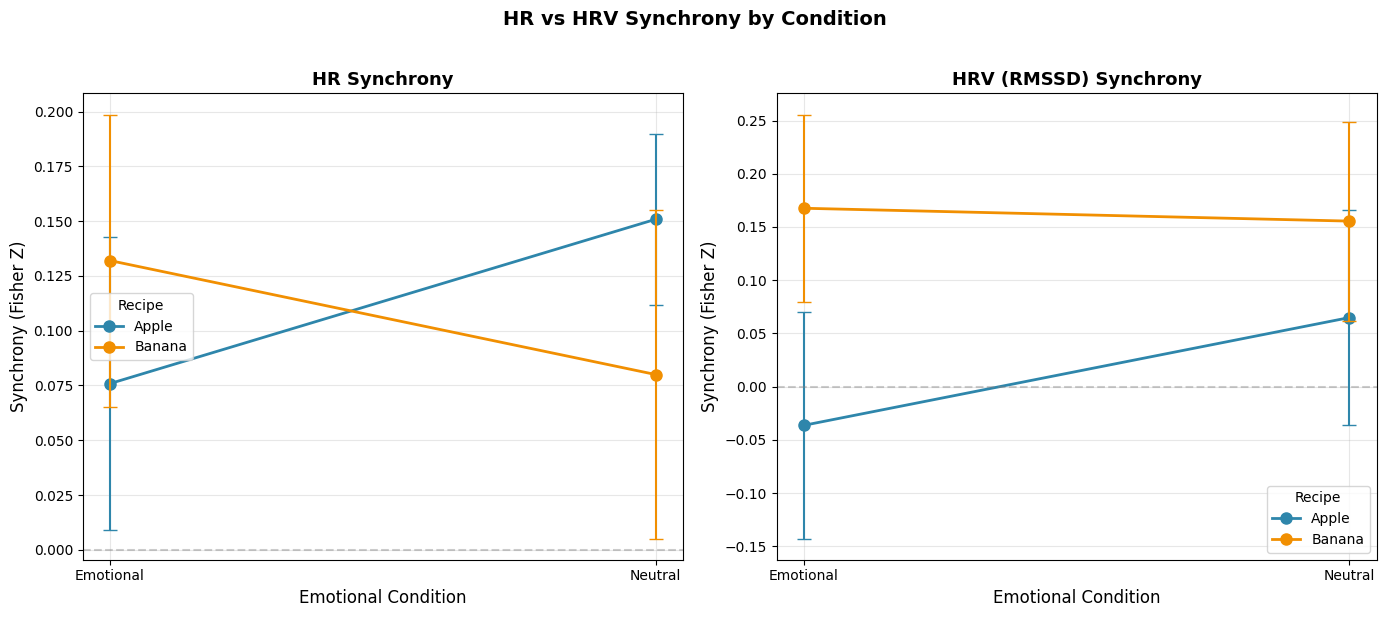

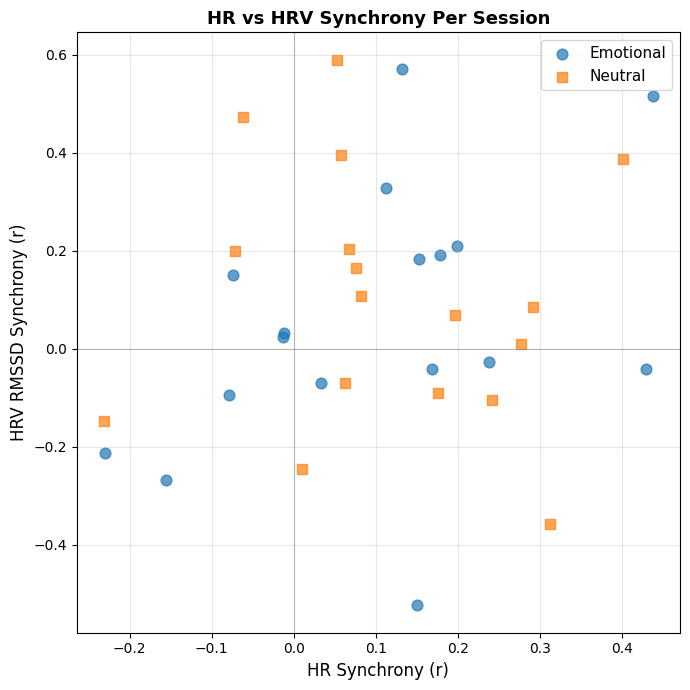


✓ All results saved to /Users/rachelsong/Desktop/Movesense/hrv_synchrony_results/


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# ── Config ───────────────────────────────────────────────────
processed_data_dir = Path("/Users/rachelsong/Desktop/Movesense/processed_data")
hr_sync_dir        = Path("/Users/rachelsong/Desktop/Movesense/hr_synchrony_results")
output_dir         = Path("/Users/rachelsong/Desktop/Movesense/hrv_synchrony_results")
output_dir.mkdir(parents=True, exist_ok=True)

WINDOW_SEC  = 30   # rolling window size in seconds
STEP_FRAC   = 0.5  # 50% overlap


# ── Helper: compute RMSSD from RR intervals ──────────────────
def compute_rmssd(rr_ms):
    """RMSSD from an array of RR intervals in milliseconds."""
    rr = np.array(rr_ms, dtype=float)
    rr = rr[~np.isnan(rr)]
    if len(rr) < 2:
        return np.nan
    diffs = np.diff(rr)
    return np.sqrt(np.mean(diffs ** 2))


# ── Helper: windowed RMSSD ───────────────────────────────────
def windowed_rmssd(rr_series, timestamps, window_sec=30, step_frac=0.5):
    """
    Compute RMSSD in rolling windows.
    Returns arrays of (window_center_sec, rmssd_value).
    """
    centers = []
    values  = []
    duration = timestamps[-1] - timestamps[0]
    step_sec = window_sec * step_frac

    t_start = timestamps[0]
    while t_start + window_sec <= timestamps[-1]:
        t_end = t_start + window_sec
        mask  = (timestamps >= t_start) & (timestamps < t_end)
        rr_window = rr_series[mask]
        rmssd = compute_rmssd(rr_window)
        centers.append(t_start + window_sec / 2)
        values.append(rmssd)
        t_start += step_sec

    return np.array(centers), np.array(values)


# ── Helper: IQR cleaning ─────────────────────────────────────
def clean_series(arr, multiplier=3.0):
    arr = arr.copy().astype(float)
    Q1  = np.nanpercentile(arr, 25)
    Q3  = np.nanpercentile(arr, 75)
    IQR = Q3 - Q1
    lower, upper = Q1 - multiplier * IQR, Q3 + multiplier * IQR
    arr[(arr < lower) | (arr > upper)] = np.nan
    # interpolate gaps
    s = pd.Series(arr)
    s = s.interpolate(method='linear').ffill().bfill()
    return s.values


# ── Load participants CSV ────────────────────────────────────
participants_df = pd.read_csv("/Users/rachelsong/Desktop/Movesense/COGS 402 Participants - Sheet.csv")
participants_df.columns = [c.strip().lower().replace(' ', '_') for c in participants_df.columns]

sensor_cohort_to_participant = {}
for _, row in participants_df.iterrows():
    sensor_id = str(int(row['sensor_id']))
    cohort    = row['participant_cohort']
    sensor_cohort_to_participant[(sensor_id, cohort)] = int(row['participant_id'])

cohort_conditions = {}
for _, row in participants_df.iterrows():
    cohort = row['participant_cohort']
    cond   = row['condition']
    if pd.notna(cond) and str(cond).strip():
        parts = [c.strip() for c in str(cond).strip().split(',')]
        if len(parts) == 2:
            cohort_conditions[cohort] = {'phase1': parts[0], 'phase2': parts[1]}

cohort_participants = {}
for cohort, group in participants_df.groupby('participant_cohort'):
    cohort_participants[cohort] = list(group['participant_id'].astype(int))

print(f"✓ Participant data loaded — {len(cohort_conditions)} cohorts with conditions")


# ── Main loop ────────────────────────────────────────────────
hr_records  = []
hrv_records = []

for session_dir in sorted(processed_data_dir.iterdir()):
    if not session_dir.is_dir():
        continue

    metadata_file = session_dir / 'metadata.json'
    hr_sync_file  = hr_sync_dir / session_dir.name / 'synchrony_results.json'

    if not metadata_file.exists():
        continue
    if not hr_sync_file.exists():
        print(f"⚠️ No HR sync results for {session_dir.name} — skipping")
        continue

    with open(metadata_file) as f:
        metadata = json.load(f)
    with open(hr_sync_file) as f:
        hr_results = json.load(f)

    cohort  = metadata.get('cohort')
    sensor1 = str(metadata.get('sensor_1', ''))[-4:]
    sensor2 = str(metadata.get('sensor_2', ''))[-4:]

    if not cohort or not sensor1 or not sensor2:
        continue
    if (sensor1, cohort) not in sensor_cohort_to_participant:
        continue
    if (sensor2, cohort) not in sensor_cohort_to_participant:
        continue
    if cohort not in cohort_conditions or cohort not in cohort_participants:
        continue

    p1_id   = sensor_cohort_to_participant[(sensor1, cohort)]
    p2_id   = sensor_cohort_to_participant[(sensor2, cohort)]
    ordered = cohort_participants[cohort]

    if len(ordered) != 4:
        continue

    p1_pos = ordered.index(p1_id) if p1_id in ordered else -1
    p2_pos = ordered.index(p2_id) if p2_id in ordered else -1
    if p1_pos == -1 or p2_pos == -1:
        continue

    positions = sorted([p1_pos, p2_pos])
    if positions in [[0, 1], [2, 3]]:
        phase          = 1
        condition_code = cohort_conditions[cohort]['phase1']
    elif positions in [[0, 2], [1, 3]]:
        phase          = 2
        condition_code = cohort_conditions[cohort]['phase2']
    else:
        continue

    emotion = 'Emotional' if condition_code[0] == 'E' else 'Neutral'
    recipe  = 'Apple'     if condition_code[1] == 'A' else 'Banana'

    # ── Load raw HR/RR files ─────────────────────────────────
    p1_name = metadata.get('participant_1', 'Participant_A')
    p2_name = metadata.get('participant_2', 'Participant_B')

    hr_p1_file = session_dir / f"hr_{p1_name}.csv"
    hr_p2_file = session_dir / f"hr_{p2_name}.csv"

    if not hr_p1_file.exists() or not hr_p2_file.exists():
        print(f"⚠️ Missing HR files for {session_dir.name}")
        continue

    hr_p1 = pd.read_csv(hr_p1_file)
    hr_p2 = pd.read_csv(hr_p2_file)

    # ── Reconstruct timestamps from RR intervals ─────────────
    def make_timestamps(df, start_time):
        rr_sec = df['RRData'].values / 1000.0
        ts     = np.zeros(len(df))
        ts[0]  = start_time
        for i in range(1, len(df)):
            ts[i] = ts[i-1] + rr_sec[i]
        return ts - start_time  # relative seconds from start

    ts_p1 = make_timestamps(hr_p1, metadata['exp_start'])
    ts_p2 = make_timestamps(hr_p2, metadata['exp_start'])

    rr_p1 = clean_series(hr_p1['RRData'].values)
    rr_p2 = clean_series(hr_p2['RRData'].values)

    # ── Windowed RMSSD ───────────────────────────────────────
    centers_p1, rmssd_p1 = windowed_rmssd(rr_p1, ts_p1, WINDOW_SEC, STEP_FRAC)
    centers_p2, rmssd_p2 = windowed_rmssd(rr_p2, ts_p2, WINDOW_SEC, STEP_FRAC)

    # Align to common windows
    min_windows = min(len(rmssd_p1), len(rmssd_p2))
    if min_windows < 3:
        print(f"⚠️ Too few windows for {session_dir.name} — skipping HRV")
        continue

    rmssd_p1 = rmssd_p1[:min_windows]
    rmssd_p2 = rmssd_p2[:min_windows]
    centers  = centers_p1[:min_windows]

    # Remove windows where either is NaN
    valid = ~np.isnan(rmssd_p1) & ~np.isnan(rmssd_p2)
    if valid.sum() < 3:
        print(f"⚠️ Too many NaN windows for {session_dir.name} — skipping HRV")
        continue

    rmssd_p1_clean = rmssd_p1[valid]
    rmssd_p2_clean = rmssd_p2[valid]

    # ── RMSSD correlation ────────────────────────────────────
    from scipy import stats
    hrv_r, hrv_p = stats.pearsonr(rmssd_p1_clean, rmssd_p2_clean)
    hrv_r_clipped = np.clip(hrv_r, -0.9999, 0.9999)
    hrv_fisher_z  = np.arctanh(hrv_r_clipped)

    # ── HR synchrony (from existing results) ─────────────────
    hr_r = hr_results.get('overall_r')
    if hr_r is None or np.isnan(hr_r):
        continue
    hr_r_clipped = np.clip(hr_r, -0.9999, 0.9999)
    hr_fisher_z  = np.arctanh(hr_r_clipped)

    base_record = {
        'session'          : session_dir.name,
        'cohort'           : cohort,
        'participant_1_id' : p1_id,
        'participant_2_id' : p2_id,
        'phase'            : phase,
        'condition_code'   : condition_code,
        'emotion'          : emotion,
        'recipe'           : recipe,
        'duration_seconds' : metadata['duration_seconds'],
    }

    hr_records.append({**base_record,
                       'overall_r' : hr_r,
                       'fisher_z'  : hr_fisher_z})

    hrv_records.append({**base_record,
                        'rmssd_r'      : hrv_r,
                        'hrv_fisher_z' : hrv_fisher_z,
                        'mean_rmssd_p1': float(np.nanmean(rmssd_p1)),
                        'mean_rmssd_p2': float(np.nanmean(rmssd_p2))})

    print(f"✓ {session_dir.name} | {emotion} {recipe} | HR r={hr_r:.3f} | HRV r={hrv_r:.3f}")

# ── Build dataframes ─────────────────────────────────────────
df_hr  = pd.DataFrame(hr_records)
df_hrv = pd.DataFrame(hrv_records)
df     = pd.merge(df_hr, df_hrv[['session', 'rmssd_r', 'hrv_fisher_z',
                                   'mean_rmssd_p1', 'mean_rmssd_p2']],
                  on='session')

print(f"\n{'='*60}")
print(f"Total sessions analyzed: {len(df)}")
print(f"\nCondition breakdown:")
print(df.groupby(['emotion', 'recipe']).size().reset_index(name='n'))


# ── Descriptive statistics ───────────────────────────────────
print(f"\n{'='*60}")
print("DESCRIPTIVE STATISTICS")
print(f"{'='*60}")

desc_hr = df.groupby(['emotion', 'recipe'])['fisher_z'].agg(['mean', 'std', 'count'])
desc_hr.columns = ['HR Mean Fisher Z', 'HR SD', 'N']

desc_hrv = df.groupby(['emotion', 'recipe'])['hrv_fisher_z'].agg(['mean', 'std'])
desc_hrv.columns = ['HRV Mean Fisher Z', 'HRV SD']

desc = pd.concat([desc_hr, desc_hrv], axis=1)
print(desc.to_string())


# ── ANOVA: HR synchrony ──────────────────────────────────────
print(f"\n{'='*60}")
print("2x2 ANOVA — HR SYNCHRONY")
print(f"{'='*60}")
model_hr   = ols('fisher_z ~ C(emotion) + C(recipe) + C(emotion):C(recipe)', data=df).fit()
anova_hr   = anova_lm(model_hr, typ=2)
anova_hr['partial_eta_sq'] = anova_hr['sum_sq'] / (
    anova_hr['sum_sq'] + anova_hr.loc['Residual', 'sum_sq'])
print(anova_hr.to_string())


# ── ANOVA: HRV synchrony ─────────────────────────────────────
print(f"\n{'='*60}")
print("2x2 ANOVA — HRV (RMSSD) SYNCHRONY")
print(f"{'='*60}")
model_hrv  = ols('hrv_fisher_z ~ C(emotion) + C(recipe) + C(emotion):C(recipe)', data=df).fit()
anova_hrv  = anova_lm(model_hrv, typ=2)
anova_hrv['partial_eta_sq'] = anova_hrv['sum_sq'] / (
    anova_hrv['sum_sq'] + anova_hrv.loc['Residual', 'sum_sq'])
print(anova_hrv.to_string())


# ── Plot: side-by-side interaction plots ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
colors = {'Apple': '#2E86AB', 'Banana': '#F18F01'}

for ax, measure, label in zip(axes,
                               ['fisher_z',    'hrv_fisher_z'],
                               ['HR Synchrony', 'HRV (RMSSD) Synchrony']):
    for recipe in ['Apple', 'Banana']:
        subset = df[df['recipe'] == recipe].groupby('emotion')[measure].agg(['mean', 'sem'])
        ax.plot(subset.index, subset['mean'], 'o-', linewidth=2, markersize=8,
                color=colors[recipe], label=recipe)
        ax.errorbar(subset.index, subset['mean'], yerr=subset['sem'],
                    fmt='none', color=colors[recipe], capsize=5)
    ax.set_xlabel('Emotional Condition', fontsize=12)
    ax.set_ylabel('Synchrony (Fisher Z)', fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(title='Recipe', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('HR vs HRV Synchrony by Condition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(output_dir / 'hr_vs_hrv_synchrony.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Plot: scatter HR r vs HRV r per session ──────────────────
fig, ax = plt.subplots(figsize=(7, 7))
for emotion, marker in [('Emotional', 'o'), ('Neutral', 's')]:
    subset = df[df['emotion'] == emotion]
    ax.scatter(subset['overall_r'], subset['rmssd_r'],
               marker=marker, s=60, alpha=0.7, label=emotion)

ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlabel('HR Synchrony (r)', fontsize=12)
ax.set_ylabel('HRV RMSSD Synchrony (r)', fontsize=12)
ax.set_title('HR vs HRV Synchrony Per Session', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'hr_vs_hrv_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Save combined results ────────────────────────────────────
df.to_csv(output_dir / 'hr_hrv_combined.csv', index=False)
anova_hr.to_csv(output_dir  / 'anova_hr.csv')
anova_hrv.to_csv(output_dir / 'anova_hrv.csv')

print(f"\n✓ All results saved to {output_dir}/")